<a href="https://colab.research.google.com/github/gangulaumesh-dep/CVLAB8/blob/main/CVLAB7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

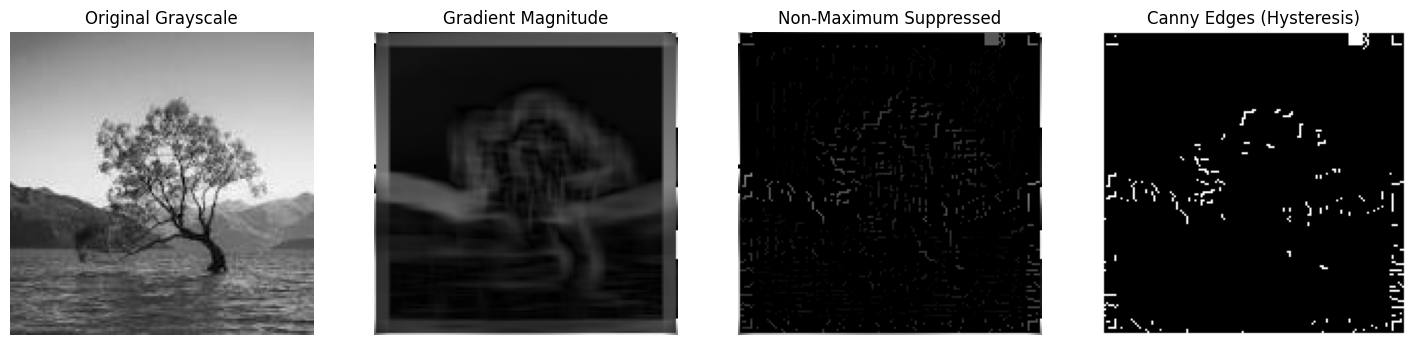

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def filtering(img_input, kernel_input, p, s):
    # Ensure image is grayscale for convolution
    if len(img_input.shape) == 3:
        img_input = cv2.cvtColor(img_input, cv2.COLOR_BGR2GRAY)

    img_height, img_width = img_input.shape
    kernel_height, kernel_width = kernel_input.shape

    # Calculate output dimensions using the provided formula
    output_height = (img_height - kernel_height + 2 * p) // s + 1
    output_width = (img_width - kernel_width + 2 * p) // s + 1

    # Apply padding to the input image
    if p != 0:
        padded_image = np.pad(img_input, p, mode='constant', constant_values=0)
    else:
        padded_image = img_input

    # Initialize output image with float32 for intermediate calculations
    output_image = np.zeros((output_height, output_width), dtype=np.float32)

    # Iterate over the output image to find every pixel intensity value
    for i in range(output_height):
        for j in range(output_width):
            y_start = i * s
            x_start = j * s

            # Extract the region of interest (ROI) from the padded image
            roi = padded_image[y_start : y_start + kernel_height,
                               x_start : x_start + kernel_width]

            # Perform element-wise multiplication and sum, checking for valid ROI size
            if roi.shape == kernel_input.shape:
                output_image[i, j] = np.sum(roi * kernel_input)
            else:
                # This case should ideally not happen with correct padding/output size calculation
                output_image[i, j] = 0 # Set to zero if ROI is not valid

    return output_image

k = 15 # User defined kernel size
img = cv2.imread("/content/drive/MyDrive/im1.jpg") # Load the image

if img is None:
    print("Error: Could not load image from /content/drive/MyDrive/im1.jpg")
else:
    # Convert image to grayscale and float32 for processing
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)

    # Use user-defined kernel and filtering function for blurring
    kernel = np.ones((k, k)) / (k * k)
    # Calculate padding for 'same' convolution for the blur kernel
    pad_size_blur = (k - 1) // 2
    filtered_img = filtering(img_gray, kernel, p=pad_size_blur, s=1)

    # Sobel operators
    sobel_x = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)
    sobel_y = sobel_x.T.astype(np.float32)

    # Apply Sobel filters using the filtering function (p=1 for 3x3 kernel for 'same' convolution)
    grad_x = filtering(filtered_img, sobel_x, p=1, s=1)
    grad_y = filtering(filtered_img, sobel_y, p=1, s=1)

    # Calculate gradient magnitude and orientation
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    # arctan2 handles division by zero and gives angles in [-pi, pi]
    orientation = np.arctan2(grad_y, grad_x)
    orientation = np.abs(np.degrees(orientation)) % 180 # Map to [0, 180) degrees

    # Quantize orientation into 4 directions (0, 45, 90, 135 degrees)
    m, n = orientation.shape
    # Initialize quantized_orientation with zeros, will be filled with 0, 45, 90, 135
    quantized_orientation = np.zeros_like(orientation, dtype=int)

    for i in range(m):
        for j in range(n):
            angle = orientation[i,j]
            if (angle >= 0 and angle < 22.5) or (angle >= 157.5 and angle <= 180):
                quantized_orientation[i,j] = 0
            elif angle >= 22.5 and angle < 67.5:
                quantized_orientation[i,j] = 45
            elif angle >= 67.5 and angle < 112.5:
                quantized_orientation[i,j] = 90
            elif angle >= 112.5 and angle < 157.5:
                quantized_orientation[i,j] = 135

    # Non-Maximum Suppression
    suppressed_magnitude = np.copy(magnitude)
    M, N = magnitude.shape # Use M, N from magnitude shape

    for i in range(1, M - 1):
        for j in range(1, N - 1):
            angle = quantized_orientation[i, j]

            q, r = 0, 0 # Initialize neighbor magnitudes

            # Compare current pixel's magnitude with its two neighbors along the gradient direction
            if angle == 0: # Horizontal (0 degrees or 180 degrees)
                q = magnitude[i, j + 1] # Neighbor to the right
                r = magnitude[i, j - 1] # Neighbor to the left
            elif angle == 45: # Diagonal (45 degrees)
                q = magnitude[i - 1, j + 1] # Top-right neighbor
                r = magnitude[i + 1, j - 1] # Bottom-left neighbor
            elif angle == 90: # Vertical (90 degrees)
                q = magnitude[i + 1, j] # Bottom neighbor
                r = magnitude[i - 1, j] # Top neighbor
            elif angle == 135: # Diagonal (135 degrees)
                q = magnitude[i - 1, j - 1] # Top-left neighbor
                r = magnitude[i + 1, j + 1] # Bottom-right neighbor

            # If the current pixel's magnitude is not greater than both neighbors, suppress it
            if magnitude[i, j] < q or magnitude[i, j] < r:
                suppressed_magnitude[i, j] = 0

    # Hysteresis Thresholding
    # Set arbitrary high and low thresholds based on the max magnitude
    T_high = np.max(suppressed_magnitude) * 0.09 # A common heuristic
    T_low = T_high * 0.05 # A common heuristic

    strong_edges = (suppressed_magnitude >= T_high)
    weak_edges_candidates = (suppressed_magnitude >= T_low) & (suppressed_magnitude < T_high)

    # Initialize final Canny edge map
    canny_edges = np.zeros_like(magnitude, dtype=np.uint8)
    canny_edges[strong_edges] = 255 # Mark strong edges as 255

    # Define 8-connected neighborhood coordinates
    neighbourhood_coords = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]

    # Connect weak edges to strong edges (single pass for simplicity as per user's style)
    # A more robust implementation would iterate until no more weak edges are connected
    for i in range(1, M - 1):
        for j in range(1, N - 1):
            if weak_edges_candidates[i, j]:
                # Check if any strong edge is in the 8-connected neighborhood
                for dy, dx in neighbourhood_coords:
                    if strong_edges[i + dy, j + dx]:
                        canny_edges[i, j] = 255 # Promote weak edge to strong
                        break # Move to the next pixel once connected

    # Display results
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 4, 1)
    plt.imshow(img_gray.astype(np.uint8), cmap='gray')
    plt.title('Original Grayscale')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(magnitude.astype(np.uint8), cmap='gray') # Convert to uint8 for display
    plt.title('Gradient Magnitude')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(suppressed_magnitude.astype(np.uint8), cmap='gray') # Convert to uint8 for display
    plt.title('Non-Maximum Suppressed')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(canny_edges, cmap='gray')
    plt.title('Canny Edges (Hysteresis)')
    plt.axis('off')

    plt.show()